# TP : Fine-tuning
Use case : Classification de sentiments sur des avis clients  <br>
Objectif : Benchmark des méthodes d'adaptation d'un LLM générique (fine-tuning, complet, LoRA, distillation) <br>
Modèle utilisé : DistilGPT-2 / Pythia-160m  <br>

## 1. Configuration de l'environnement

In [ ]:
!pip install transformers datasets accelerate evaluate peft -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.4 MB/s eta 0:00:00


**transformers :** La bibliothèque principale de Hugging Face pour utiliser les modèles pré-entraînés. <br>
**datasets :** Une bibliothèque pour charger et manipuler facilement des jeux de données. <br>
**accelerate :** Permet de lancer le même code sur CPU, GPU ou plusieurs GPU sans modification. <br>
**evaluate :** Fournit des outils pour évaluer les modèles. <br>
**-q (quiet) :** Installe les bibliothèques sans afficher tous les détails de l'installation.

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
import torch.nn.functional as F
from transformers import AutoConfig
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

**torch :** Bibliothèque de deep learning (similaire à TensorFlow) sur laquelle les modèles Hugging Face sont basés.

**numpy :** Pour les calculs numériques, notamment avec les tableaux.

**pandas :** Pour manipuler les données sous forme de tableaux (DataFrames).

**matplotlib.pyplot, seaborn :** Pour créer des graphiques et des visualisations.

**datasets :** Pour convertir nos données au format attendu par Hugging Face.

**transformers :** <br>
**AutoTokenizer :** Charge automatiquement le bon "tokenizer" (qui transforme le texte en chiffres) pour un modèle donné.  <br>
**AutoModelForSequenceClassification :** Charge un modèle pré-entraîné avec une tête de classification ajoutée par-dessus.  <br>
**TrainingArguments, Trainer :** Outils qui simplifient grandement l'entraînement des modèles.  <br>
**pipeline :** Une interface très simple pour faire des prédictions.

**sklearn :** Bibliothèque de Machine Learning classique.  <br>
**metrics :** Pour calculer les scores de performance (précision, F1-score, etc.).  <br>
**train_test_split :** Pour diviser les données en un ensemble d'entraînement et un ensemble de test.

**warnings.filterwarnings('ignore') :** Ignore les avertissements non critiques pour garder une sortie propre.

In [ ]:
# Configuration
torch.manual_seed(42)
np.random.seed(42)

print(f"🔧 Device disponible : {'GPU' if torch.cuda.is_available() else 'CPU'}")


🔧 Device disponible : CPU


**torch.manual_seed(42)** et **np.random.seed(42)** : Ces lignes fixent le point de départ des générateurs de nombres aléatoires. C'est crucial pour la reproductibilité. Quiconque exécute ce code obtiendra les mêmes résultats "aléatoires" (comme l'initialisation des poids du modèle ou le mélange des données). Le nombre 42 est une convention populaire.

**torch.cuda.is_available() :** Vérifie si un GPU est détecté et utilisable. L'entraînement est beaucoup plus rapide sur GPU.

## 2. Génération du dataset

In [ ]:
def generer_dataset_sentiments():
    """
    1. Génère un dataset d'avis clients avec labels de sentiment
    """

    # Avis POSITIFS
    avis_positifs = [
        "Ce produit est absolument fantastique ! Je le recommande vivement.",
        "Excellente qualité, livraison rapide, très satisfait de mon achat.",
        "Meilleur achat de l'année, correspond parfaitement à mes attentes.",
        "Service client exceptionnel, produit de haute qualité.",
        "Je suis ravi de cette acquisition, rapport qualité-prix imbattable.",
        "Produit remarquable, fonctionne à merveille, très content.",
        "Superbe article, exactement ce que je cherchais, bravo !",
        "Vraiment impressionné par la qualité, je recommande sans hésiter.",
        "Parfait en tout point, livraison soignée, produit impeccable.",
        "Excellent produit, conforme à la description, très satisfait.",
        "Un achat que je ne regrette pas du tout, qualité au top.",
        "Produit formidable, dépasse mes espérances, je suis conquis.",
        "Service irréprochable, produit de qualité exceptionnelle.",
        "Très bon rapport qualité prix, je suis vraiment content.",
        "Article parfait, correspond exactement à mes besoins.",
        "Magnifique produit, excellente finition, très bonne qualité.",
        "Je recommande les yeux fermés, produit exceptionnel.",
        "Vraiment top, rien à redire, parfait du début à la fin.",
        "Excellent achat, produit conforme et de qualité supérieure.",
        "Très satisfait, produit fonctionnel et esthétique.",
    ]

    # Avis NÉGATIFS
    avis_negatifs = [
        "Très déçu par ce produit, qualité médiocre et service client inexistant.",
        "Arnaque totale, produit cassé à la livraison, aucun remboursement.",
        "Mauvaise qualité, ne correspond pas du tout à la description.",
        "Je déconseille fortement, perte de temps et d'argent.",
        "Produit défectueux dès réception, service après-vente lamentable.",
        "Catastrophique, article inutilisable, je suis très mécontent.",
        "Qualité déplorable, matériaux cheap, vraiment décevant.",
        "N'achetez pas ce produit, c'est de l'arnaque pure et simple.",
        "Horrible expérience, produit défaillant, aucun support client.",
        "Très mauvaise surprise, produit bas de gamme, je regrette.",
        "Déception totale, rien ne fonctionne correctement.",
        "Produit de mauvaise qualité, casse facilement, à éviter.",
        "Service client nul, produit défectueux, aucune solution proposée.",
        "Je ne recommande absolument pas, qualité déplorable.",
        "Arnaque, produit reçu différent de la photo, très énervé.",
        "Mauvais achat, produit qui ne tient pas dans le temps.",
        "Qualité honteuse pour ce prix, complètement insatisfait.",
        "À fuir absolument, produit médiocre et SAV inexistant.",
        "Grande déception, matériaux fragiles, casse rapidement.",
        "Expérience désastreuse du début à la fin, je déconseille.",
    ]

    # Avis NEUTRES
    avis_neutres = [
        "Le produit est correct, sans plus, fait le job.",
        "Conforme à la description, qualité moyenne mais acceptable.",
        "Rien d'exceptionnel mais ça fonctionne, prix correct.",
        "Produit standard, répond aux attentes basiques.",
        "Pas mal mais pas extraordinaire non plus, dans la moyenne.",
        "Correct pour le prix, qualité acceptable mais améliorable.",
        "Produit moyen, quelques défauts mais globalement utilisable.",
        "Ça fait ce qu'on lui demande, sans surprise particulière.",
        "Qualité correcte, rien de spécial à signaler.",
        "Produit basique qui remplit sa fonction, pas plus.",
        "Ni bon ni mauvais, un produit lambda dans cette gamme.",
        "Acceptable, correspond à un produit d'entrée de gamme.",
        "Fait le travail mais sans grande conviction.",
        "Produit ordinaire, ne se distingue pas particulièrement.",
        "Correct mais j'ai vu mieux ailleurs pour le même prix.",
        "Fonctionnel mais design et qualité moyens.",
        "Ça va, produit standard sans innovation particulière.",
        "Assez basique, remplit sa fonction principale.",
        "Produit convenable, quelques petits défauts mineurs.",
        "Moyen, pas déçu mais pas enthousiasmé non plus.",
    ]

    # Création du dataset
    textes = avis_positifs + avis_negatifs + avis_neutres
    labels = [2] * len(avis_positifs) + [0] * len(avis_negatifs) + [1] * len(avis_neutres)

        # 2. Augmentation des données (variation légère)
    textes_augmentes = []
    labels_augmentes = []

    for texte, label in zip(textes, labels):
        # Original
        textes_augmentes.append(texte)
        labels_augmentes.append(label)

        # Variation 1 : Ajout de ponctuation
        textes_augmentes.append(texte + "!")
        labels_augmentes.append(label)

        # Variation 2 : Minuscules
        textes_augmentes.append(texte.lower())
        labels_augmentes.append(label)

        df = pd.DataFrame({
        'text': textes_augmentes,
        'label': labels_augmentes
    })

    # 3. Mélange
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)

    return df

Une fonction est définie pour créer un jeu de données de test.

Trois listes de chaînes de caractères (**avis_positifs, avis_negatifs, avis_neutres**) sont créées manuellement.

**textes = ... :** Concatène les trois listes en une seule grande liste de textes.

**labels = ... :** Crée une liste d'étiquettes correspondante. <br>
[2] * len(avis_positifs) : Répète le label 2 (positif) autant de fois qu'il y a d'avis positifs. <br>
[0] pour négatif, [1] pour neutre.

-------

Ensuite, on utilise une technique simple d'augmentation de données pour tripler la taille du dataset.

Pour chaque avis original, on en crée trois versions : l'original, l'original avec un "!", et l'original en minuscules.

Cela aide le modèle à devenir plus robuste et à ne pas être sensible à la casse ou à une ponctuation simple.

-------

**pd.DataFrame(...) :** Crée un tableau (DataFrame) pandas avec deux colonnes : text et label.

**df.sample(frac=1, random_state=42) :** Mélange toutes les lignes du DataFrame de manière aléatoire (frac=1 signifie 100% des lignes). **random_state=42** assure que le mélange est toujours le même.

**.reset_index(drop=True) :** Après le mélange, les index des lignes sont désordonnés. Cette commande réinitialise l'index à 0, 1, 2, ... et supprime l'ancien index.

In [ ]:
df = generer_dataset_sentiments()

print(f"\n✅ Dataset généré : {len(df)} exemples")
print(f"\n📊 Distribution des labels :")
label_names = {0: 'Négatif', 1: 'Neutre', 2: 'Positif'}
for label, count in df['label'].value_counts().sort_index().items():
    print(f"   {label_names[label]:10s} : {count:3d} exemples ({count/len(df)*100:.1f}%)")

print("\n📝 Exemples d'avis :")
for i in range(3):
    row = df.iloc[i]
    print(f"\n   Label : {label_names[row['label']]}")
    print(f"   Texte : {row['text'][:80]}...")


✅ Dataset généré : 180 exemples

📊 Distribution des labels :
   Négatif    :  60 exemples (33.3%)
   Neutre     :  60 exemples (33.3%)
   Positif    :  60 exemples (33.3%)

📝 Exemples d'avis :

   Label : Positif
   Texte : Superbe article, exactement ce que je cherchais, bravo !!...

   Label : Positif
   Texte : Article parfait, correspond exactement à mes besoins....

   Label : Neutre
   Texte : Acceptable, correspond à un produit d'entrée de gamme....


Appelle la fonction pour créer le DataFrame, puis affiche sa taille, la distribution des classes et quelques exemples pour vérifier que tout s'est bien passé.

In [ ]:
df.to_csv('datasetFT_CG_v1.csv', index=False)

In [ ]:
# Split train/test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
print(f"\n✅ Split effectué :")
print(f"   Train : {len(train_df)} exemples")
print(f"   Test  : {len(test_df)} exemples")


✅ Split effectué :
   Train : 144 exemples
   Test  : 36 exemples


Divise le jeu de données en deux parties :

**train_df (80% des données) :** servira à entraîner le modèle.

**test_df (20% des données) :** servira à évaluer le modèle sur des données qu'il n'a jamais vues.

**stratify=df['label'] :** C'est une option très importante. Elle garantit que la proportion de labels (positifs, négatifs, neutres) est la même dans l'ensemble d'entraînement et de test.

## 3. Chargement du modèle pré-entraîné (Baseline)

In [ ]:
model_name = "distilgpt2"

# Chargement du tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Configuration importante pour GPT-2
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Chargement du modèle de base (AVANT fine-tuning)
print("\n🔵 Chargement du modèle BASELINE (non fine-tuné)...")
model_baseline = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    problem_type="single_label_classification"
)
model_baseline.config.pad_token_id = tokenizer.pad_token_id

print("✅ Modèle baseline chargé avec succès")
print(f"   Nombre de paramètres : {model_baseline.num_parameters():,}")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: distilgpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Modèle baseline chargé avec succès
   Nombre de paramètres : 81,914,880


**model_name = "distilgpt2" :** Définit le nom du modèle à utiliser depuis le Hugging Face Hub.

**AutoTokenizer.from_pretrained(...) :** Télécharge et charge le tokenizer associé à DistilGPT-2. Le tokenizer convertit les phrases en une suite de nombres (tokens) compréhensibles par le modèle.

**if tokenizer.pad_token is None: :** Les modèles comme GPT-2 n'ont pas de token de "remplissage" (padding) par défaut car ils ont été conçus pour générer du texte. Pour la classification, on en a besoin pour que toutes les phrases d'un même lot aient la même longueur. Cette ligne assigne le token de fin de phrase (eos_token) comme token de remplissage, une pratique courante

-----

**AutoModelForSequenceClassification.from_pretrained(...) :** Télécharge le modèle DistilGPT-2 pré-entraîné et y ajoute une "tête" de classification (*dernière couche d'un réseau de neurones qui transforme les features apprises en probabilités de classes*). <br>
**num_labels=3 :** On lui précise qu'il y a 3 classes de sortie possibles. <br>
**problem_type="..." :** Spécifie le type de tâche.

**model_baseline.config.pad_token_id = ... :** Synchronise la configuration du modèle avec celle du tokenizer pour qu'ils utilisent le même token de remplissage.

Ce modèle est appelé **model_baseline** car il n'a pas encore été fine-tuné sur nos données.

## 4. Fine-tuning complet

In [ ]:
# 1. Préparation des datasets pour Hugging Face
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=128,
        padding="max_length"
    )

# 2. Conversion en Dataset Hugging Face
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Tokenization
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format PyTorch
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

print(f"✅ Datasets préparés pour le fine-tuning")

# 3. Nouveau modèle pour le fine-tuning
print("\n🟢 Initialisation d'un nouveau modèle pour le fine-tuning...")
model_finetuned = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    problem_type="single_label_classification"
)
model_finetuned.config.pad_token_id = tokenizer.pad_token_id

# 4. Configuration du training (corrigée)
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=50,
    weight_decay=0.01,
    #logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    push_to_hub=False,
    report_to="none"
)


# 5. Fonction de calcul des métriques
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# 6. Trainer
trainer = Trainer(
    model=model_finetuned,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# 7. Fine-tuning
print("\n🚀 Début du fine-tuning...")
print("   (Cela peut prendre quelques minutes selon votre machine)")
print("-" * 60)

train_result = trainer.train()

print("\n✅ Fine-tuning terminé !")
print(f"   Loss finale : {train_result.training_loss:.4f}")

Map:   0%|          | 0/144 [00:00<?, ? examples/s]

Map:   0%|          | 0/36 [00:00<?, ? examples/s]

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `1`.


✅ Datasets préparés pour le fine-tuning

🟢 Initialisation d'un nouveau modèle pour le fine-tuning...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,3.015426,1.318228,0.305556,0.301587,0.305556,0.281765
2,1.155757,1.075641,0.333333,0.111111,0.333333,0.166667
3,0.874952,0.637208,0.777778,0.842593,0.777778,0.772222


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning terminé !
   Loss finale : 1.5115


1.
Crée une fonction qui prend un lot d'exemples et applique le tokenizer sur la colonne 'text'. C'est le format requis par la bibliothèque **datasets**.

---
2.
**Dataset.from_pandas(...) :** Convertit les DataFrames pandas en objets Dataset de Hugging Face.

**.map(tokenize_function, batched=True) :** Applique la fonction de tokenization à l'ensemble du dataset. **batched=True** la rend beaucoup plus rapide.

**.set_format(...) :** Formate le dataset pour qu'il retourne des tenseurs PyTorch, prêts à être utilisés par le modèle.

---

3.
Charge une nouvelle instance du modèle pré-entraîné. Il est important de ne pas réutiliser **model_baseline** pour que le fine-tuning parte bien du modèle d'origine.

---

4.

Crée un objet pour configurer tous les aspects de l'entraînement.

**output_dir :** Dossier où sauvegarder les résultats et les modèles.

**num_train_epochs=3 :** Le modèle verra l'ensemble des données d'entraînement 3 fois.

**per_device_train_batch_size=8 :** Le modèle traitera les données par lots de 8 exemples.

**eval_strategy="epoch" :** L'évaluation sur le jeu de test sera faite à la fin de chaque époque.

**load_best_model_at_end=True :** À la fin de l'entraînement, charge automatiquement la version du modèle qui a eu les meilleurs résultats lors de l'évaluation.

---

5.
Crée une fonction que le **Trainer** utilisera pour calculer les métriques de performance pendant l'évaluation.

---

6.
Instancie l'objet **Trainer**. C'est le chef d'orchestre qui combine le modèle, les arguments d'entraînement, les datasets et la fonction de métriques.

---

7.
Cette unique ligne de code lance tout le processus de fine-tuning. Le **Trainer** s'occupe de la boucle d'entraînement, des optimisations, de l'évaluation, de la sauvegarde, etc.

### Rappel : Losses

**Training Loss :** Erreur sur les données d'entraînement (le modèle "apprend par cœur")

**Validation Loss :** Erreur sur des données jamais vues (le modèle "comprend vraiment")

La Loss guide l'entraînement, l'Accuracy/Precision/Recall valident le résultat final.

## 5. LoRA

In [ ]:
# Contournement temporaire : on indique à peft que torchao n'est pas disponible
import sys
for nom, module in list(sys.modules.items()):
    if nom.startswith("peft") and hasattr(module, "is_torchao_available"):
        module.is_torchao_available = lambda: False

In [ ]:
# 1. Charger un modèle frais pour l'entraînement LoRA
print("\\n🔵 Initialisation d'un nouveau modèle pour le fine-tuning LoRA...")
model_lora = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    problem_type="single_label_classification"
)
model_lora.config.pad_token_id = tokenizer.pad_token_id

# 2. Définir la configuration de LoRA
#    r: La dimension du rang (plus c'est petit, moins de paramètres à entraîner)
#    lora_alpha: Le facteur d'échelle pour les poids LoRA
#    target_modules: Les couches du modèle sur lesquelles appliquer LoRA. Pour GPT-2, 'c_attn' est la couche d'attention clé.
#    task_type: Spécifie la tâche pour configurer correctement le modèle
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["c_attn"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS
)

# 3. Appliquer LoRA au modèle
print("   Application de la configuration LoRA au modèle...")
model_lora = get_peft_model(model_lora, lora_config)

# Afficher le nombre de paramètres entraînables pour voir la différence !
print("\\n📊 Comparaison des paramètres entraînables :")
def print_trainable_parameters(model, model_name="model"):
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(
        f"   - {model_name}: {trainable_params:,} paramètres entraînables ({100 * trainable_params / all_param:.4f}%)"
    )

print_trainable_parameters(model_finetuned, "Modèle Complet")
print_trainable_parameters(model_lora, "Modèle LoRA")


# 4. Entraîner avec le Trainer (le même Trainer sait gérer un modèle PEFT)
trainer_lora = Trainer(
    model=model_lora,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# 5. Lancer le fine-tuning LoRA
print("\\n🚀 Début du fine-tuning LoRA...")
print("-" * 60)
train_result_lora = trainer_lora.train()

print("\\n✅ Fine-tuning LoRA terminé !")
print(f"   Loss finale : {train_result_lora.training_loss:.4f}")

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `1`.


\n🔵 Initialisation d'un nouveau modèle pour le fine-tuning LoRA...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: distilgpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Application de la configuration LoRA au modèle...
\n📊 Comparaison des paramètres entraînables :
   - Modèle Complet: 81,914,880 paramètres entraînables (100.0000%)
   - Modèle LoRA: 149,760 paramètres entraînables (0.1825%)
\n🚀 Début du fine-tuning LoRA...
------------------------------------------------------------


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.043677,2.181231,0.333333,0.111111,0.333333,0.166667
2,2.137654,1.916083,0.333333,0.111111,0.333333,0.166667
3,1.677962,1.551164,0.333333,0.111111,0.333333,0.166667


\n✅ Fine-tuning LoRA terminé !
   Loss finale : 1.9604


## 6. Distillation



In [ ]:
# 1. Le "professeur" est notre modèle BASELINE (non fine-tuné)
teacher_model = model_baseline
teacher_model.eval() # Mettre le professeur en mode évaluation

# 2. Créer un modèle "élève" plus petit
#    On utilise la même architecture (GPT-2) mais avec moins de couches et une taille cachée plus faible.
print("\n🔵 Création du modèle élève (student)...")
student_config = AutoConfig.from_pretrained(
    model_name,
    num_labels=3,
    problem_type="single_label_classification",
    n_layer=3,  # distilgpt2 a 6 couches, on en met 3
    n_head=4,   # distilgpt2 a 12 têtes, on en met 4
    n_embd=256, # distilgpt2 a 768, on met 256
)
student_config.pad_token_id = tokenizer.pad_token_id

student_model = AutoModelForSequenceClassification.from_config(student_config)

print("\n📊 Comparaison des tailles de modèles :")
print(f"   - Professeur : {teacher_model.num_parameters():,} paramètres")
print(f"   - Élève      : {student_model.num_parameters():,} paramètres")


# 3. Créer un Trainer personnalisé pour la distillation
class DistillationTrainer(Trainer):
    def __init__(self, *args, teacher_model=None, alpha=0.5, temperature=2.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.teacher_model = teacher_model
        self.alpha = alpha
        self.temperature = temperature

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Sorties de l'élève
        outputs_student = model(**inputs)
        loss_ce = outputs_student.loss # Loss classique avec les vrais labels
        logits_student = outputs_student.logits

        # Sorties du professeur
        with torch.no_grad():
            outputs_teacher = self.teacher_model(**inputs)
            logits_teacher = outputs_teacher.logits

        # Calcul de la loss de distillation (KL Divergence)
        loss_kd = F.kl_div(
            F.log_softmax(logits_student / self.temperature, dim=-1),
            F.softmax(logits_teacher / self.temperature, dim=-1),
            reduction='batchmean'
        ) * (self.temperature ** 2)

        # Combinaison des deux losses
        loss = self.alpha * loss_ce + (1 - self.alpha) * loss_kd

        return (loss, outputs_student) if return_outputs else loss

# 4. Instancier le DistillationTrainer
#    alpha: poids de la loss classique (0.5 = 50% CE, 50% KD)
#    temperature: "adoucit" les probabilités du professeur pour donner plus d'infos à l'élève
trainer_distill = DistillationTrainer(
    model=student_model,
    teacher_model=teacher_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    alpha=0.5,
    temperature=2.0,
)

# 5. Lancer l'entraînement par distillation
print("\n🚀 Début de l'entraînement par distillation...")
print("-" * 60)
train_result_distill = trainer_distill.train()

print("\n✅ Distillation terminée !")
print(f"   Loss finale : {train_result_distill.training_loss:.4f}")

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `1`.



🔵 Création du modèle élève (student)...

📊 Comparaison des tailles de modèles :
   - Professeur : 81,914,880 paramètres
   - Élève      : 15,498,496 paramètres

🚀 Début de l'entraînement par distillation...
------------------------------------------------------------


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.525005,1.178707,0.333333,0.111111,0.333333,0.166667
2,1.178813,1.083969,0.333333,0.111111,0.333333,0.166667
3,1.025914,0.987011,0.361111,0.447619,0.361111,0.221495


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Distillation terminée !
   Loss finale : 1.1732


## 7. Benchmark

### 7.1. Évaluation

In [ ]:
import time

def evaluer_modele(model, test_df, tokenizer, nom_modele):
    """Évalue un modèle sur le test set : métriques + temps d'inférence"""

    print(f"\n🔍 Évaluation de : {nom_modele}")
    print("-" * 60)

    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    predictions = []
    temps = []

    with torch.no_grad():
        # Préchauffage : les premières prédictions sont toujours plus lentes
        for text in test_df['text'][:5]:
            model(**tokenizer(text, return_tensors="pt", truncation=True,
                              max_length=128, padding="max_length").to(device))

        for text in test_df['text']:
            # Tokenization
            inputs = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                max_length=128,
                padding="max_length"
            ).to(device)

            # Prédiction chronométrée
            if torch.cuda.is_available(): torch.cuda.synchronize()
            debut = time.perf_counter()
            outputs = model(**inputs)
            if torch.cuda.is_available(): torch.cuda.synchronize()
            temps.append(time.perf_counter() - debut)

            pred = torch.argmax(outputs.logits, dim=-1).item()
            predictions.append(pred)

    temps_inference_ms = np.mean(temps) * 1000

    # Calcul des métriques
    y_true = test_df['label'].values
    y_pred = np.array(predictions)

    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    print(f"   Accuracy  : {accuracy:.4f}")
    print(f"   Precision : {precision:.4f}")
    print(f"   Recall    : {recall:.4f}")
    print(f"   F1-Score  : {f1:.4f}")
    print(f"   Temps d'inférence : {temps_inference_ms:.2f} ms / avis")

    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)

    return {
        'name': nom_modele,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': y_pred,
        'confusion_matrix': cm,
        'inference_time_ms': temps_inference_ms
    }

In [ ]:
    results_baseline = evaluer_modele(model_baseline, test_df, tokenizer, "MODÈLE BASELINE")


🔍 Évaluation de : MODÈLE BASELINE
------------------------------------------------------------
   Accuracy  : 0.3333
   Precision : 0.1111
   Recall    : 0.3333
   F1-Score  : 0.1667
   Temps d'inférence : 281.13 ms / avis


In [ ]:
    results_finetuned = evaluer_modele(model_finetuned, test_df, tokenizer, "MODÈLE FINE-TUNÉ")


🔍 Évaluation de : MODÈLE FINE-TUNÉ
------------------------------------------------------------
   Accuracy  : 0.7778
   Precision : 0.8426
   Recall    : 0.7778
   F1-Score  : 0.7722
   Temps d'inférence : 283.45 ms / avis


In [ ]:
# On compte les paramètres entraînables AVANT la fusion (après, les matrices LoRA n'existent plus)
nb_params_lora = sum(p.numel() for p in model_lora.parameters() if p.requires_grad)

# Pour LoRA, il faut fusionner les poids avant l'évaluation pour une inférence plus rapide
model_lora_merged = model_lora.merge_and_unload()
results_lora = evaluer_modele(model_lora_merged, test_df, tokenizer, "MODÈLE LoRA")


🔍 Évaluation de : MODÈLE LoRA
------------------------------------------------------------
   Accuracy  : 0.3333
   Precision : 0.1111
   Recall    : 0.3333
   F1-Score  : 0.1667
   Temps d'inférence : 302.37 ms / avis


In [ ]:
results_distilled = evaluer_modele(student_model, test_df, tokenizer, "MODÈLE DISTILLÉ")


🔍 Évaluation de : MODÈLE DISTILLÉ
------------------------------------------------------------
   Accuracy  : 0.3611
   Precision : 0.4476
   Recall    : 0.3611
   F1-Score  : 0.2215
   Temps d'inférence : 22.09 ms / avis


### 7.2. Visualisations

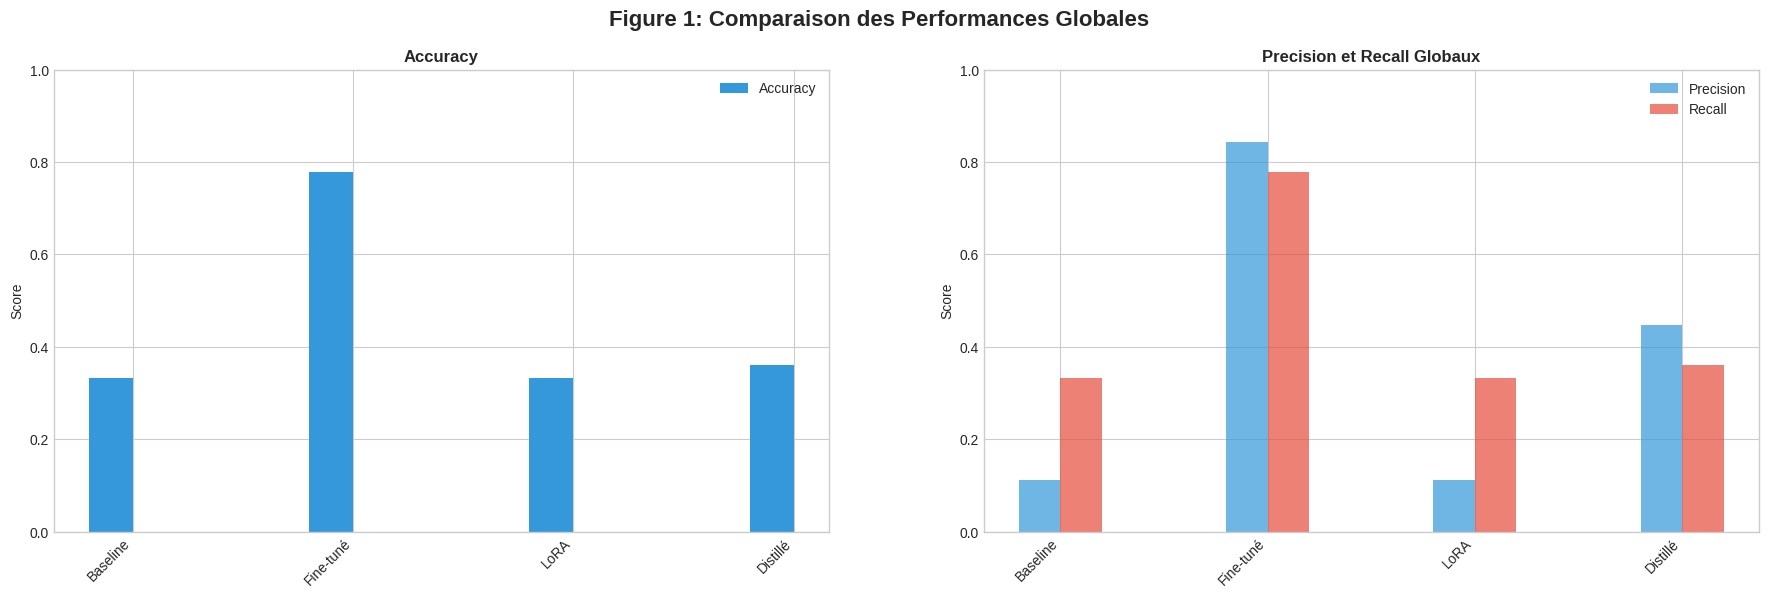

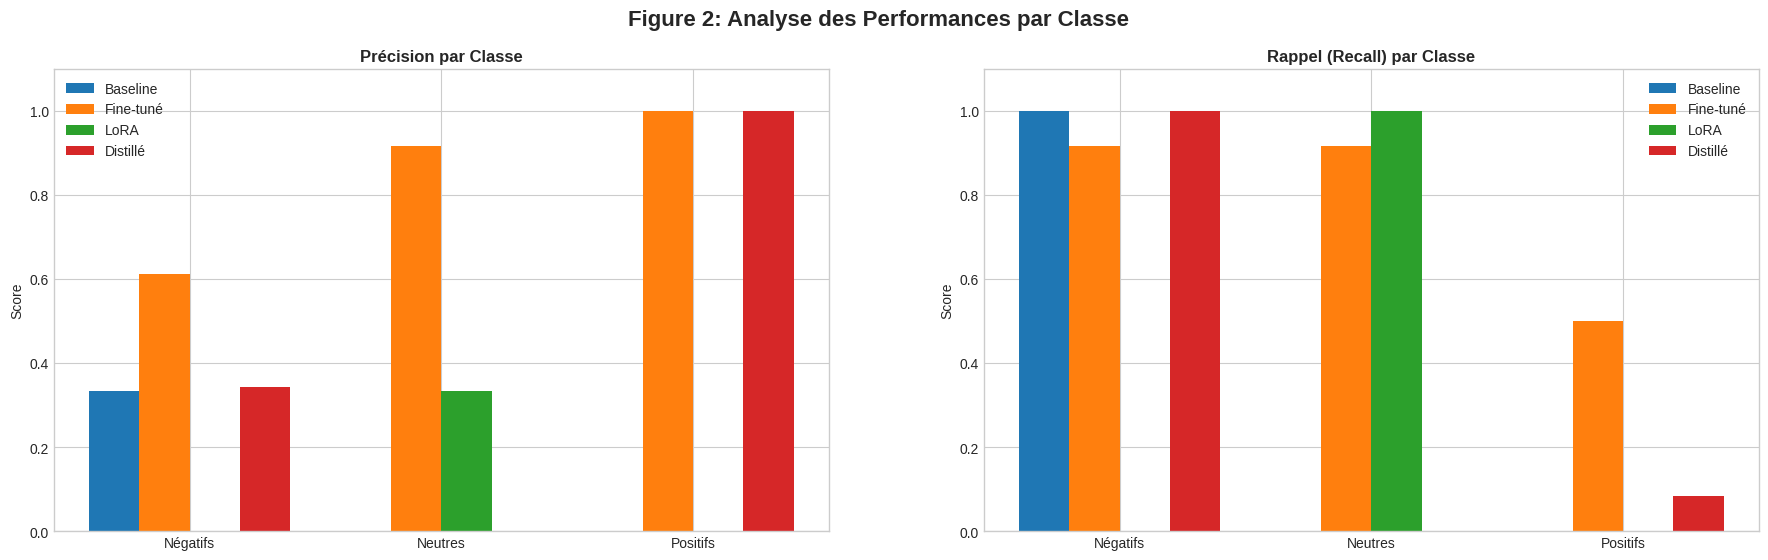

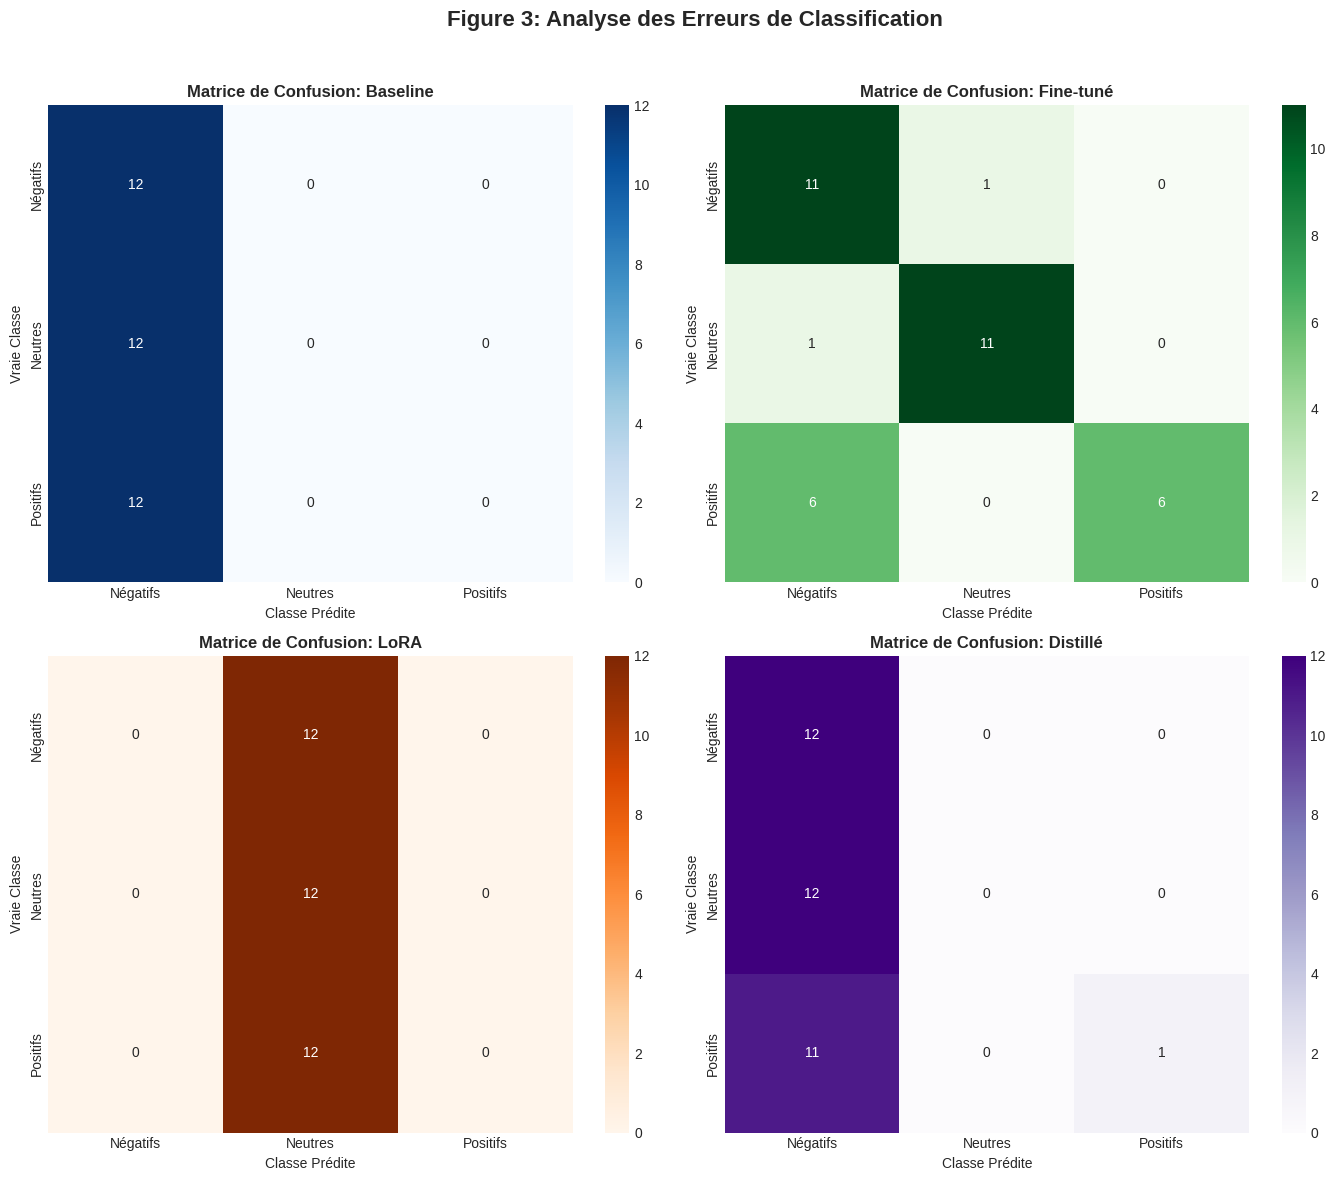

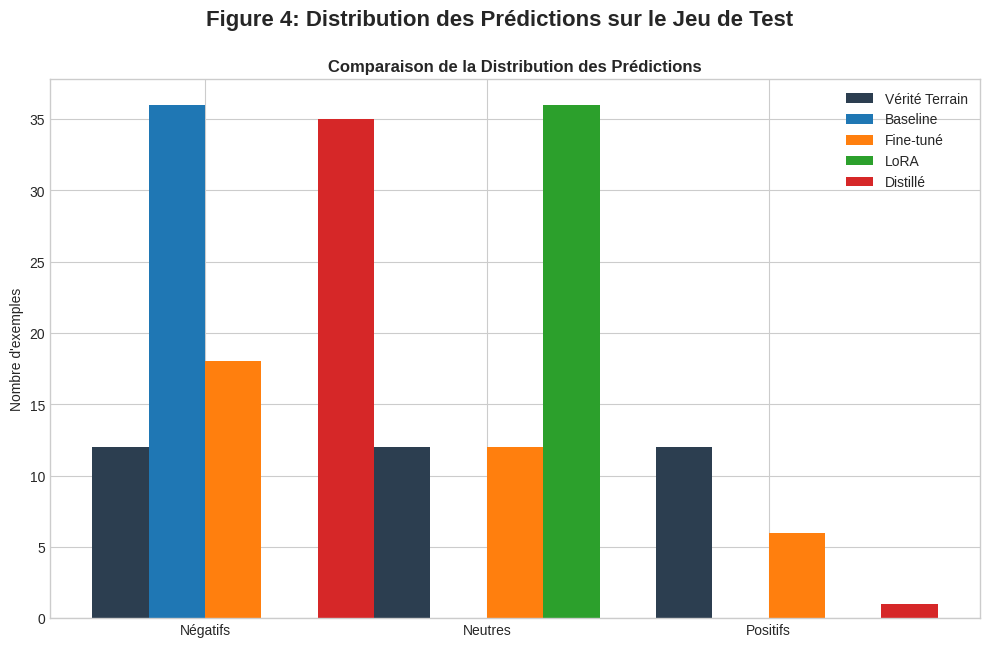

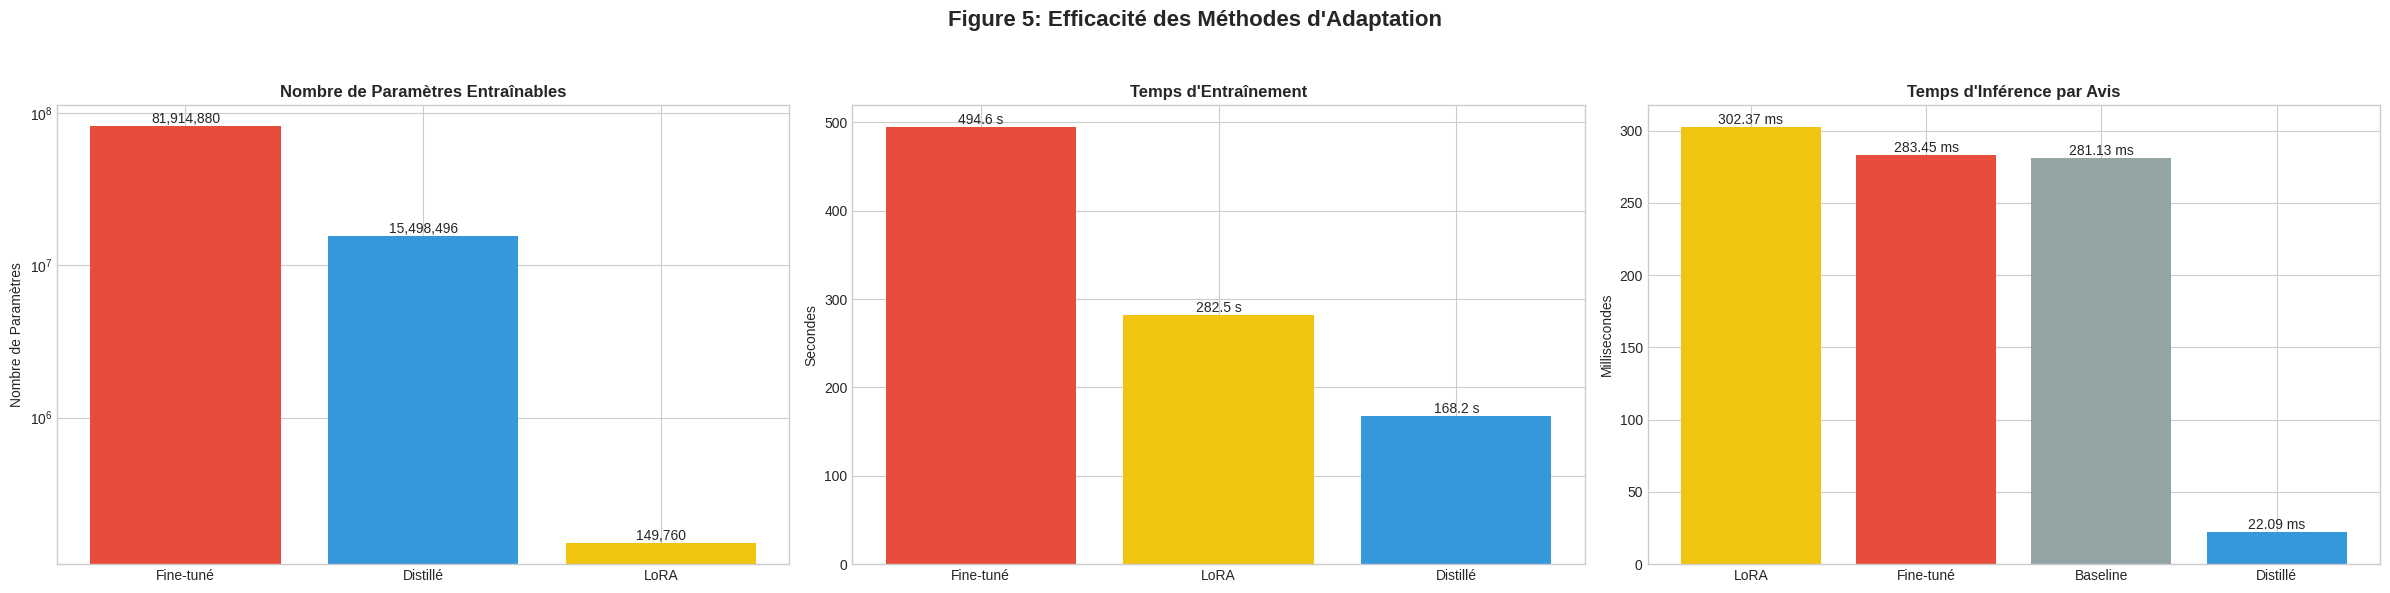

In [ ]:
# ==============================================================================
# 0. PRÉPARATION DES DONNÉES POUR LES GRAPHIQUES
# ==============================================================================

y_true = test_df['label'].values
# Ordre des classes = ordre des labels numériques : 0 = Négatif, 1 = Neutre, 2 = Positif
labels = ['Négatifs', 'Neutres', 'Positifs']

# Noms des modèles pour les graphiques
model_names = ['Baseline', 'Fine-tuné', 'LoRA', 'Distillé']

# Performances globales
results_data = {
    'Baseline': results_baseline,
    'Fine-tuné': results_finetuned,
    'LoRA': results_lora,
    'Distillé': results_distilled
}

# Calcul des métriques par classe (Precision, Recall, F1)
per_class_metrics = {model: {'precision': [], 'recall': [], 'f1': []} for model in model_names}

for model_name, results in results_data.items():
    cm = results['confusion_matrix']
    # Precision: TP / (TP + FP)
    precision_scores = np.diag(cm) / np.sum(cm, axis=0)
    # Recall: TP / (TP + FN)
    recall_scores = np.diag(cm) / np.sum(cm, axis=1)
    # F1-Score: 2 * (Precision * Recall) / (Precision + Recall)
    f1_scores = 2 * (precision_scores * recall_scores) / (precision_scores + recall_scores)

    per_class_metrics[model_name]['precision'] = np.nan_to_num(precision_scores) # Remplacer NaN par 0 si une classe n'est jamais prédite
    per_class_metrics[model_name]['recall'] = np.nan_to_num(recall_scores)
    per_class_metrics[model_name]['f1'] = np.nan_to_num(f1_scores)

# Efficacité (nombre de paramètres entraînables)
def get_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

trainable_params = {
    'Fine-tuné': get_trainable_parameters(model_finetuned),
    'LoRA': nb_params_lora,
    'Distillé': get_trainable_parameters(student_model) # L'élève est entraîné entièrement
}

# Temps d'entraînement
# On accède au temps via le dictionnaire 'metrics' et on utilise 'train_runtime'
training_times_data = {}
try:
    if 'train_result' in locals() and hasattr(train_result, 'metrics') and 'train_runtime' in train_result.metrics:
        training_times_data['Fine-tuné'] = train_result.metrics['train_runtime']
    else:
        training_times_data['Fine-tuné'] = 0
        print("Note: Temps d'entraînement pour 'Fine-tuné' non disponible.")

    if 'train_result_lora' in locals() and hasattr(train_result_lora, 'metrics') and 'train_runtime' in train_result_lora.metrics:
        training_times_data['LoRA'] = train_result_lora.metrics['train_runtime']
    else:
        training_times_data['LoRA'] = 0
        print("Note: Temps d'entraînement pour 'LoRA' non disponible.")

    if 'train_result_distill' in locals() and hasattr(train_result_distill, 'metrics') and 'train_runtime' in train_result_distill.metrics:
        training_times_data['Distillé'] = train_result_distill.metrics['train_runtime']
    else:
        training_times_data['Distillé'] = 0
        print("Note: Temps d'entraînement pour 'Distillé' non disponible.")

except Exception as e:
    print(f"Erreur lors de la récupération des temps d'entraînement : {e}")
    training_times_data = {'Fine-tuné': 0, 'LoRA': 0, 'Distillé': 0}

# Temps d'inférence moyen par avis (mesuré dans evaluer_modele)
inference_times_data = {name: results_data[name]['inference_time_ms'] for name in model_names}

# Couleurs fixes par modèle (restent cohérentes même après tri)
couleurs = {'Baseline': '#95a5a6', 'Fine-tuné': '#e74c3c', 'LoRA': '#f1c40f', 'Distillé': '#3498db'}

# ==============================================================================
# 1. GRAPHIQUES DE PERFORMANCE GLOBALE
# ==============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 6))
fig1.suptitle('Figure 1: Comparaison des Performances Globales', fontsize=16, fontweight='bold')

# --- Graphique 1.1: Accuracy ---
metrics_bar = ['Accuracy']
scores = {model: [results_data[model]['accuracy']] for model in model_names}
x = np.arange(len(model_names))
width = 0.2
colors = ['#3498db', '#e74c3c']

for i, metric in enumerate(metrics_bar):
    metric_scores = [scores[model][i] for model in model_names]
    ax1.bar(x + i*width, metric_scores, width, label=metric, color=colors[i])

ax1.set_title('Accuracy', fontweight='bold')
ax1.set_ylabel('Score')
ax1.set_xticks(x + width/2)
ax1.set_xticklabels(model_names, rotation=45, ha='right')
ax1.set_ylim(0, 1)
ax1.legend()

# --- Graphique 1.2: Precision et Recall ---
metrics_bar2 = ['Precision', 'Recall']
scores2 = {model: [results_data[model]['precision'], results_data[model]['recall']] for model in model_names}
for i, metric in enumerate(metrics_bar2):
    metric_scores = [scores2[model][i] for model in model_names]
    ax2.bar(x + i*width, metric_scores, width, label=metric, color=colors[i], alpha=0.7)

ax2.set_title('Precision et Recall Globaux', fontweight='bold')
ax2.set_ylabel('Score')
ax2.set_xticks(x + width/2)
ax2.set_xticklabels(model_names, rotation=45, ha='right')
ax2.set_ylim(0, 1)
ax2.legend()

# ==============================================================================
# 2. GRAPHIQUES D'ANALYSE PAR CLASSE
# ==============================================================================
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 6))
fig2.suptitle('Figure 2: Analyse des Performances par Classe', fontsize=16, fontweight='bold')

x = np.arange(len(labels))
width = 0.2

# --- Graphique 2.1: Precision par Classe ---
for i, model_name in enumerate(model_names):
    scores = per_class_metrics[model_name]['precision']
    ax1.bar(x - width*1.5 + i*width, scores, width, label=model_name)
ax1.set_title('Précision par Classe', fontweight='bold')
ax1.set_ylabel('Score')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylim(0, 1.1)
ax1.legend()

# --- Graphique 2.2: Recall par Classe ---
for i, model_name in enumerate(model_names):
    scores = per_class_metrics[model_name]['recall']
    ax2.bar(x - width*1.5 + i*width, scores, width, label=model_name)
ax2.set_title('Rappel (Recall) par Classe', fontweight='bold')
ax2.set_ylabel('Score')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylim(0, 1.1)
ax2.legend()

# ==============================================================================
# 3. GRAPHIQUES D'ANALYSE DES ERREURS
# ==============================================================================
fig3, axes = plt.subplots(2, 2, figsize=(14, 12))
fig3.suptitle('Figure 3: Analyse des Erreurs de Classification', fontsize=16, fontweight='bold')
axes = axes.flatten()

# --- Graphiques 3.1 à 3.4: Matrices de Confusion ---
for i, model_name in enumerate(model_names):
    cm = results_data[model_name]['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues' if i == 0 else ('Greens' if i==1 else ('Oranges' if i==2 else 'Purples')),
                ax=axes[i], xticklabels=labels, yticklabels=labels)
    axes[i].set_title(f'Matrice de Confusion: {model_name}', fontweight='bold')
    axes[i].set_xlabel('Classe Prédite')
    axes[i].set_ylabel('Vraie Classe')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# --- Graphique 3.5: Distribution des Prédictions ---
fig4, ax4 = plt.subplots(figsize=(12, 7))
fig4.suptitle('Figure 4: Distribution des Prédictions sur le Jeu de Test', fontsize=16, fontweight='bold')

true_dist = pd.Series(y_true).value_counts().sort_index()
x = np.arange(len(labels))
width = 0.2

# Vérité terrain
ax4.bar(x - width*1.5, true_dist.values, width, label='Vérité Terrain', color='#2c3e50')

# Prédictions des modèles
for i, model_name in enumerate(model_names):
    pred_dist = pd.Series(results_data[model_name]['predictions']).value_counts().reindex([0, 1, 2], fill_value=0).sort_index()
    ax4.bar(x - width*0.5 + i*width, pred_dist.values, width, label=model_name)

ax4.set_title('Comparaison de la Distribution des Prédictions', fontweight='bold')
ax4.set_ylabel('Nombre d\'exemples')
ax4.set_xticks(x)
ax4.set_xticklabels(labels)
ax4.legend()
plt.show()

# ==============================================================================
# 4. GRAPHIQUES D'EFFICACITÉ DES MÉTHODES
# ==============================================================================
fig5, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))
fig5.suptitle('Figure 5: Efficacité des Méthodes d\'Adaptation', fontsize=16, fontweight='bold')

# --- Graphique 4.1: Nombre de Paramètres Entraînables ---
params_df = pd.DataFrame.from_dict(trainable_params, orient='index', columns=['Paramètres'])
params_df = params_df.sort_values('Paramètres', ascending=False)
bars = ax1.bar(params_df.index, params_df['Paramètres'], color=[couleurs[n] for n in params_df.index])
ax1.set_title('Nombre de Paramètres Entraînables', fontweight='bold')
ax1.set_ylabel('Nombre de Paramètres')
ax1.set_yscale('log') # Échelle logarithmique pour mieux voir les différences
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval, f'{int(yval):,}', va='bottom', ha='center')

# --- Graphique 4.2: Temps d'Entraînement ---
times_df = pd.DataFrame.from_dict(training_times_data, orient='index', columns=['Temps (s)'])
times_df = times_df.sort_values('Temps (s)', ascending=False)
bars = ax2.bar(times_df.index, times_df['Temps (s)'], color=[couleurs[n] for n in times_df.index])
ax2.set_title('Temps d\'Entraînement', fontweight='bold')
ax2.set_ylabel('Secondes')
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.1f} s', va='bottom', ha='center')

# --- Graphique 4.3: Temps d'Inférence ---
inf_df = pd.DataFrame.from_dict(inference_times_data, orient='index', columns=['Temps (ms)'])
inf_df = inf_df.sort_values('Temps (ms)', ascending=False)
bars = ax3.bar(inf_df.index, inf_df['Temps (ms)'], color=[couleurs[n] for n in inf_df.index])
ax3.set_title('Temps d\'Inférence par Avis', fontweight='bold')
ax3.set_ylabel('Millisecondes')
for bar in bars:
    yval = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f} ms', va='bottom', ha='center')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

### Rappel : métriques d'évaluation

**Matrice de Confusion :**

   
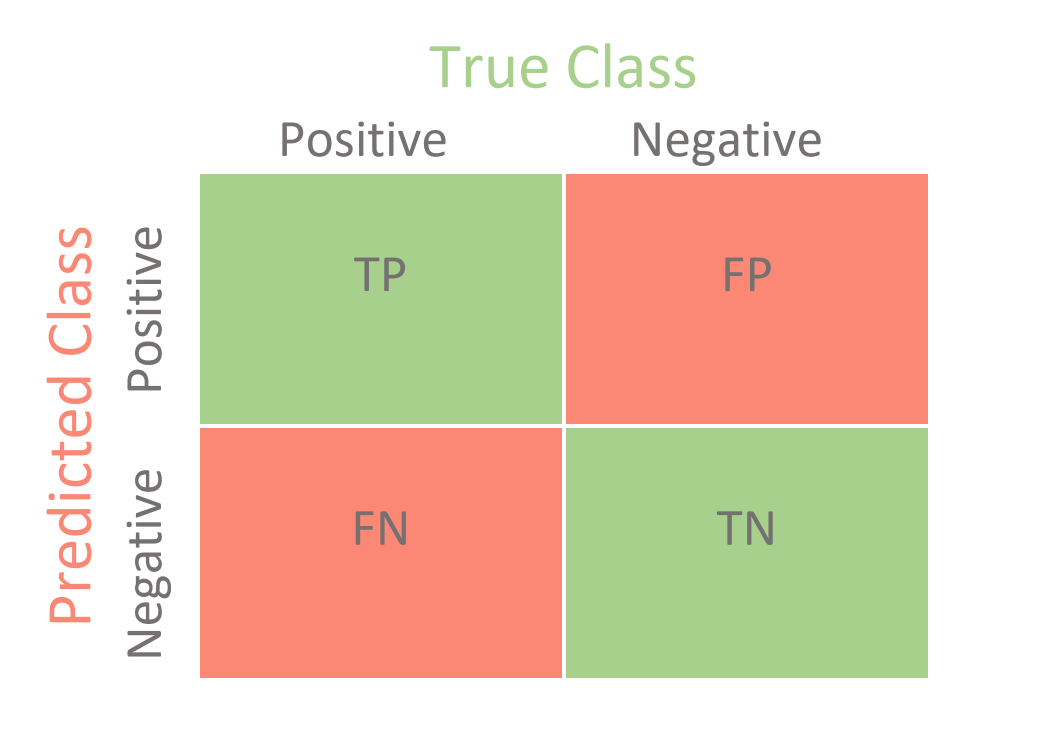

TP (Vrais Positifs) : Correctement identifiés comme positifs <br>
FP (Faux Positifs) : Négatifs incorrectement identifiés comme positifs <br>
FN (Faux Négatifs) : Positifs incorrectement identifiés comme négatifs <br>
TN (Vrais Négatifs) : Correctement identifiés comme négatifs


**Accruracy (Exactitude) :** Pourcentage de prédictions correctes parmi toutes les prédictions. <br>
**Formule :** (TP + TN) / (TP + TN + FP + FN) <br>
*"Dans l'ensemble, je me trompe rarement"*

--

**Precision (Précision) :** Quand le modèle prédit "positif", à quel point a-t-il raison ? <br>
**Formule :** TP / (TP + FP) : (Vrais Positifs) / (Tous les éléments prédits positifs) <br>
*"Quand je dis OUI, je suis fiable"*

**Recall (Rappel / Sensibilité) :** Parmi tous les vrais positifs, combien le modèle a-t-il su détecter ?  <br>
**Formule :** TP / (TP + FN) : (Vrais Positifs) / (Tous les éléments réellement positifs) <br>
*"Je ne laisse pas passer beaucoup de vrais OUI"*

Ex : Lorsqu'un moteur de recherche, par exemple, **retourne 30 pages web** dont seulement **20 sont pertinentes** (les vrais positifs) et **10 ne le sont pas** (les faux positifs), mais qu'il **omet 40 autres pages pertinentes** (les faux négatifs), sa **précision** est de **20/(20+10) = 2/3** et son **rappel** vaut **20/(20+40) = 1/3**.

--

**F1-Score :** Moyenne harmonique (pour pénaliser les déséquilibres extrêmes) entre Precision et Recall. <br>
**Formule :** 2 × (Precision × Recall) / (Precision + Recall) <br>
*"Mon juste milieu entre fiabilité et détection"*